# Ataque al cifrado Afín

**Alumno:** Carlos Yanes Pérez

En este notebook trabajaremos el algoritmo de Shor, con el objetivo final de implementarlo y obtener un factorizador de números enteros.

Antes de comenzar aportaré un breve diagrama de flujo para tener clara la lógica que se aplicará, asimismo se indicarán los pasos propios del algoritmo de Shor.

> El código ha sido refactorizado usando Claude Sonnet 4.6.

In [ ]:
!pip install qiskit qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.0 MB/s eta 0:00:00


En este proyecto se busca aplicar un circuito cuántico usando Grover para romper un cifrado clásico el cifrado Afín. De esta forma, será necesaria la implementación de un sumador y un multiplicador cuánticos (se hace uso de los presentes en Qiskit).

Para poder abordar este trabajo de forma correcta se parte de una premisa: conocemos un cierto texto $P$ y su cifrado pertinente $C$. Asimismo, para simplicidad, se trabajará en hexadecimal en lugar de con el alfabeto. Supongamos pues que tenemos
$$
P=7_2 = 0111\quad \text{y}\quad C=9_2=1001
$$

Notemos que, dado el cifrado afín:
$$
C=A\cdot P + B\ \mod{16}
$$

El objetivo es encontrar el par $(A, B)$, en este caso podría ser $(A, B)=(3, 4)$, en efecto, $3\cdot 7 + 4 = 25 \equiv 9 \mod{16}$.

Además, existe una restricción $\text{gcd}(A, 16)=1$, en caso contrario se perdería la información de $P$. Asimismo, podría existir otro par de claves válido.

Lo primero que debe notarse es que son necesarios, al menos, $12$ qubits para poder introducir esta información en el circuito pertinente. Asimismo, se busca la forma cuántica del cifrado Afín para crear el oráculo, de esta forma, si al aplicarlo sobre $P$ se consigue $C$ se obtendría el par $(A, B)$ (mejor dicho, todos los pares posibles).

Este problema fue trabajado también en

https://ieeexplore.ieee.org/document/10597663


In [ ]:
import qiskit
from qiskit_aer import Aer
from qiskit import QuantumCircuit

from qiskit.circuit.library import QFTGate
import numpy as np

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister

## Suma modular

https://quantum.cloud.ibm.com/docs/es/api/qiskit/qiskit.circuit.library.DraperQFTAdder


In [ ]:
from qiskit.circuit.library import DraperQFTAdder

## Producto modular
https://quantum.cloud.ibm.com/docs/es/api/qiskit/qiskit.circuit.library.RGQFTMultiplier

In [ ]:
from qiskit.circuit.library import RGQFTMultiplier

## Oráculo

### Puerta Afín

In [ ]:
def affine_gate(a, b, p, c, n):
    '''
    Puerta Afín
    '''
    qc = QuantumCircuit(a, b, p, c)
    qc.compose(RGQFTMultiplier(n, num_result_qubits=4), qubits=a[:] + p[:] + c[:], inplace=True)
    qc.compose(DraperQFTAdder(n, kind='fixed'), qubits=b[:] + c[:], inplace=True)

    return qc

### Marcado

In [ ]:
def mark_gate(c, n):
    '''
    Marcado
    '''
    qc = QuantumCircuit(c, name=f"Mark")

    qc.x(c[1])
    qc.x(c[2])


    #qc.cccz(c[0], c[1], c[2], c[3]) Pues Z=HXH
    qc.h(c[3])
    qc.mcx([c[0], c[1], c[2]], c[3])
    qc.h(c[3])


    qc.x(c[1])
    qc.x(c[2])

    return qc.to_instruction()

## Difusor

In [ ]:
def diffusor(a_reg, b_reg, n):

    # El espacio de búsqueda total tiene 2*n qubits
    num_search_qubits = 2 * n

    diff_qc = QuantumCircuit(a_reg, b_reg, name=f"Diffuser({num_search_qubits}q)")
    search_qubits = a_reg[:] + b_reg[:]

    # Aplicar HX-MCZ-XH (Mejor empezar en el estado |-> y quitar la X aquí)

    diff_qc.h(search_qubits)
    diff_qc.x(search_qubits)

    diff_qc.h(search_qubits[-1])
    diff_qc.mcx(search_qubits[:-1], search_qubits[-1])
    diff_qc.h(search_qubits[-1])

    diff_qc.x(search_qubits)
    diff_qc.h(search_qubits)

    return diff_qc.to_instruction()

## Ensamblado

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
n = 4
a = QuantumRegister(n, name='a')
b = QuantumRegister(n, name='b')
p = QuantumRegister(n, name='p')
c = QuantumRegister(n, name='c')
qc = QuantumCircuit(a, b, p, c)

# No es necesario el estado |-> si se encarga el difusor (HX-MCZ-XH), pero es menos óptimo.
# qc.x(a)
# qc.x(b)

# Poner los registros de búsqueda 'a' y 'b' en superposición uniforme |+>
qc.h(a)
qc.h(b)

# Multiplicación por p=7
qc.x(p[0])
qc.x(p[1])
qc.x(p[2])


qc.barrier()

import math
num_iteraciones = math.floor(math.pi/4*math.sqrt(2**n)) # Van a ser 3

for _ in range(num_iteraciones):

    qc.compose(affine_gate(a, b, p, c, n), qubits=a[:] + b[:] + p[:] + c[:], inplace=True)
    qc.compose(mark_gate(c, n), qubits=c[:], inplace=True)
    qc.compose(affine_gate(a, b, p, c, n).inverse(), qubits=a[:] + b[:] + p[:] + c[:], inplace=True)

    qc.compose(diffusor(a, b, n), qubits=a[:] + b[:], inplace=True)

    qc.barrier()

In [ ]:
### Prueba
from qiskit_aer import AerSimulator
from qiskit import transpile, ClassicalRegister # Import ClassicalRegister

# Add a classical register to the circuit
bit = ClassicalRegister(2*n, name='bit')
qc.add_register(bit)


qc.measure(a[:] + b[:], bit[:])

simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
counts = simulator.run(transpiled_qc, shots=1024).result().get_counts()

profundidad = qc.depth()
print(profundidad)

qc.draw()

20


┌───┐ ░ ┌───────────────────┐                            »
  a_0: ┤ H ├─░─┤0                  ├────────────────────────────»
       ├───┤ ░ │                   │                            »
  a_1: ┤ H ├─░─┤1                  ├────────────────────────────»
       ├───┤ ░ │                   │                            »
  a_2: ┤ H ├─░─┤2                  ├────────────────────────────»
       ├───┤ ░ │                   │                            »
  a_3: ┤ H ├─░─┤3                  ├────────────────────────────»
       ├───┤ ░ │                   │┌─────────────────┐         »
  b_0: ┤ H ├─░─┤                   ├┤0                ├─────────»
       ├───┤ ░ │                   ││                 │         »
  b_1: ┤ H ├─░─┤                   ├┤1                ├─────────»
       ├───┤ ░ │                   ││                 │         »
  b_2: ┤ H ├─░─┤                   ├┤2                ├─────────»
       ├───┤ ░ │                   ││                 │         »
  b_3: ┤ H ├─░─┤                   ├┤3                ├─────────»
       ├───┤ ░ │   RGQFTMultiplier ││                 │         »
  p_0: ┤ X ├─░─┤4                  ├┤                 ├─────────»
       ├───┤ ░ │                   ││                 │         »
  p_1: ┤ X ├─░─┤5                  ├┤                 ├─────────»
       ├───┤ ░ │                   ││  DraperQFTAdder │         »
  p_2: ┤ X ├─░─┤6                  ├┤                 ├─────────»
       └───┘ ░ │                   ││                 │         »
  p_3: ──────░─┤7                  ├┤                 ├─────────»
             ░ │                   ││                 │┌───────┐»
  c_0: ──────░─┤8                  ├┤4                ├┤0      ├»
             ░ │                   ││                 ││       │»
  c_1: ──────░─┤9                  ├┤5                ├┤1      ├»
             ░ │                   ││                 ││  Mark │»
  c_2: ──────░─┤10                 ├┤6                ├┤2      ├»
             ░ │                   ││                 ││       │»
  c_3: ──────░─┤11                 ├┤7                ├┤3      ├»
             ░ └───────────────────┘└─────────────────┘└───────┘»
bit: 8/═════════════════════════════════════════════════════════»
                                                                »
«                             ┌──────────────────────┐┌───────────────┐ ░ »
«  a_0: ──────────────────────┤0                     ├┤0              ├─░─»
«                             │                      ││               │ ░ »
«  a_1: ──────────────────────┤1                     ├┤1              ├─░─»
«                             │                      ││               │ ░ »
«  a_2: ──────────────────────┤2                     ├┤2              ├─░─»
«                             │                      ││               │ ░ »
«  a_3: ──────────────────────┤3                     ├┤3              ├─░─»
«       ┌────────────────────┐│                      ││  Diffuser(8q) │ ░ »
«  b_0: ┤0                   ├┤                      ├┤4              ├─░─»
«       │                    ││                      ││               │ ░ »
«  b_1: ┤1                   ├┤                      ├┤5              ├─░─»
«       │                    ││                      ││               │ ░ »
«  b_2: ┤2                   ├┤                      ├┤6              ├─░─»
«       │                    ││                      ││               │ ░ »
«  b_3: ┤3                   ├┤                      ├┤7              ├─░─»
«       │                    ││   RGQFTMultiplier_dg │└───────────────┘ ░ »
«  p_0: ┤                    ├┤4                     ├──────────────────░─»
«       │                    ││                      │                  ░ »
«  p_1: ┤                    ├┤5                     ├──────────────────░─»
«       │  DraperQFTAdder_dg ││                      │                  ░ »
«  p_2: ┤                    ├┤6                     ├──────────────────░─»
«       │                

## Resultados

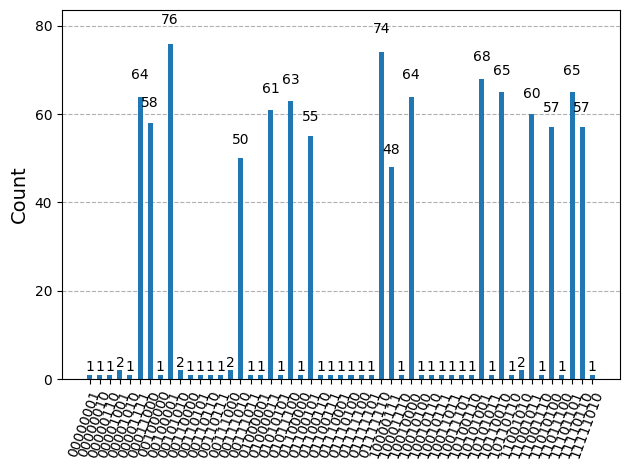

El resultado más frecuente es 00100001 con 76 ocurrencias.


In [ ]:
from qiskit.visualization import plot_histogram

display(plot_histogram(counts))

max_result = max(counts, key=counts.get)
max_count = counts[max_result]

# Imprime el resultado
print(f"El resultado más frecuente es {max_result} con {max_count} ocurrencias.")

In [ ]:
# a = int(max_result[n:], 2)
# b = int(max_result[:n], 2)

# print(f"El par (a, b) es ({a}, {b}), de modo que a * 7 + b = {(a*7+b)%16}")

In [ ]:
filtered_counts = {result: count for result, count in counts.items() if count > 40}
display(filtered_counts)

{'10101001': 68,
 '11101101': 65,
 '11010100': 57,
 '00001111': 64,
 '10000111': 48,
 '00011000': 58,
 '01111110': 74,
 '00111010': 50,
 '11001011': 60,
 '01100101': 55,
 '00100001': 76,
 '01000011': 61,
 '01011100': 63,
 '10010000': 64,
 '10110010': 65,
 '11110110': 57}

In [ ]:
for result, count in filtered_counts.items():
  a = int(result[n:], 2)
  b = int(result[:n], 2)

  print(f"Candidatos (a, b) = ({a}, {b}), tales que a * 7 + b = {(a*7+b)%16}")

Candidatos (a, b) = (9, 10), tales que a * 7 + b = 9
Candidatos (a, b) = (13, 14), tales que a * 7 + b = 9
Candidatos (a, b) = (4, 13), tales que a * 7 + b = 9
Candidatos (a, b) = (15, 0), tales que a * 7 + b = 9
Candidatos (a, b) = (7, 8), tales que a * 7 + b = 9
Candidatos (a, b) = (8, 1), tales que a * 7 + b = 9
Candidatos (a, b) = (14, 7), tales que a * 7 + b = 9
Candidatos (a, b) = (10, 3), tales que a * 7 + b = 9
Candidatos (a, b) = (11, 12), tales que a * 7 + b = 9
Candidatos (a, b) = (5, 6), tales que a * 7 + b = 9
Candidatos (a, b) = (1, 2), tales que a * 7 + b = 9
Candidatos (a, b) = (3, 4), tales que a * 7 + b = 9
Candidatos (a, b) = (12, 5), tales que a * 7 + b = 9
Candidatos (a, b) = (0, 9), tales que a * 7 + b = 9
Candidatos (a, b) = (2, 11), tales que a * 7 + b = 9
Candidatos (a, b) = (6, 15), tales que a * 7 + b = 9


Realmente solo son válidas aquellos pares donde $A$ sea coprimo con $16$, por lo que los candidatos se reducen a $8$. Si además, tenemos que $P'=2$ es cifrado como $C'=10$

In [ ]:
for result, count in filtered_counts.items():
  a = int(result[n:], 2)
  b = int(result[:n], 2)
  if (2*a+b)%16 == 10:
    print(f"El par (a, b) es ({a}, {b})")

El par (a, b) es (3, 4)
